# PCA + KNN — Optimized (K49-MNIST)

Baseline result: **87.02% mean per-class accuracy** (beats leaderboard 86.80%).

This notebook attempts to push further with three targeted optimizations:

| Optimization | Baseline | Optimized | Reason |
|---|---|---|---|
| PCA components | 60 | **tune 60–200** | More components may retain discriminative variance |
| n_neighbors | 4 | **tune 3–7** | Fewer neighbours = sharper boundaries for dense data |
| Preprocessing | /255 only | **/255 + deskew** | Deskewing corrects tilt in handwriting — major boost in literature |

**Deskewing** is the single most impactful technique for handwriting KNN — it aligns characters to a canonical orientation before PCA, meaning two samples of the same character written at slightly different angles map to nearby points in PCA space instead of distant ones.

## 1. Import Libraries

In [6]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.ndimage import affine_transform
from scipy.ndimage import center_of_mass
from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

print('✅ All libraries imported.')

✅ All libraries imported.


## 2. Load Data

In [7]:
X_train_raw = np.load('../data/k49-train-imgs.npz')['arr_0']
y_train     = np.load('../data/k49-train-labels.npz')['arr_0']
X_test_raw  = np.load('../data/k49-test-imgs.npz')['arr_0']
y_test      = np.load('../data/k49-test-labels.npz')['arr_0']

classmap     = pd.read_csv('../data/k49_classmap.csv')
target_names = [str(classmap.iloc[i]['char']) for i in range(len(classmap))]

print(f'Training images  : {X_train_raw.shape}')
print(f'Test images      : {X_test_raw.shape}')
print(f'Classes          : {len(np.unique(y_train))}')

Training images  : (232365, 28, 28)
Test images      : (38547, 28, 28)
Classes          : 49


## 3. Deskewing

**Deskewing** is the most impactful preprocessing improvement for handwriting recognition with KNN.

The idea: when someone writes a character at a slight angle, its pixel representation is tilted. Two samples of the same character written at different angles end up far apart in pixel/PCA space, making KNN think they're different characters.

Deskewing uses the **second-order moments** of the pixel intensity distribution to estimate the tilt angle and correct it, making all samples of the same character align to a canonical upright orientation.

This is a well-known technique from the digit recognition literature and works especially well for structured scripts like Hiragana.

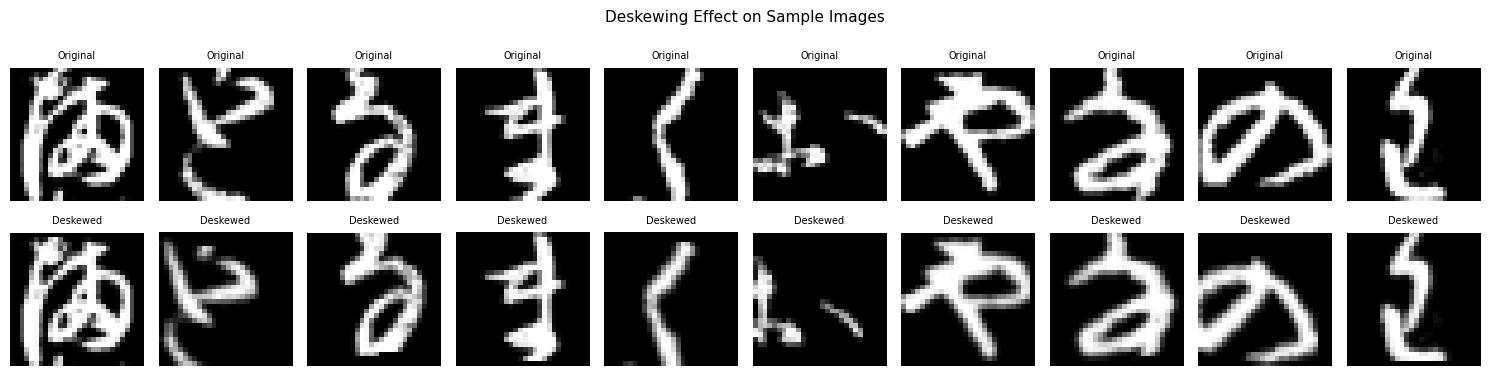

In [8]:
def deskew(image):
    """Correct tilt in a 28x28 grayscale image using moment-based deskewing."""
    if abs(image.sum()) < 1e-6:
        return image   # blank image — skip

    c0, c1 = center_of_mass(image)

    h, w = image.shape
    y_grid, x_grid = np.mgrid[:h, :w]
    mu02 = ((y_grid - c0)**2 * image).sum() / image.sum()
    mu11 = ((y_grid - c0) * (x_grid - c1) * image).sum() / image.sum()

    if mu02 < 1e-6:
        return image

    skew   = mu11 / mu02
    M      = np.array([[1, skew], [0, 1]])
    offset = np.array([0, -skew * h / 2])

    return affine_transform(image, M, offset=offset, cval=0, order=1)


def preprocess(X, apply_deskew=True):
    """Normalize, optionally deskew, and flatten images."""
    X_norm = X.astype('float32') / 255.0
    if apply_deskew:
        result = np.zeros_like(X_norm)
        for i in tqdm(range(len(X_norm)), desc='Deskewing', unit='img'):
            result[i] = deskew(X_norm[i])
        X_norm = result
    return X_norm.reshape(len(X), -1)   # flatten to 784


# Visualize deskewing effect on a few samples
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    orig = X_train_raw[i].astype('float32') / 255.0
    desk = deskew(orig)
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=7)
    axes[1, i].imshow(desk, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Deskewed', fontsize=7)
plt.suptitle('Deskewing Effect on Sample Images', fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
print('⏳ Preprocessing training set with deskewing...')
t0 = time.time()
X_train_flat = preprocess(X_train_raw, apply_deskew=True)
print(f'  Done in {time.time()-t0:.1f}s')

print('⏳ Preprocessing test set with deskewing...')
t0 = time.time()
X_test_flat = preprocess(X_test_raw, apply_deskew=True)
print(f'  Done in {time.time()-t0:.1f}s')

print(f'\nTrain shape : {X_train_flat.shape}')
print('✅ Preprocessing complete.')

⏳ Preprocessing training set with deskewing...


Deskewing: 100%|██████████| 232365/232365 [00:17<00:00, 13491.99img/s]


  Done in 17.8s
⏳ Preprocessing test set with deskewing...


Deskewing: 100%|██████████| 38547/38547 [00:03<00:00, 12269.92img/s]

  Done in 3.2s

Train shape : (232365, 784)
✅ Preprocessing complete.


## 4. Tune PCA Components

The leaderboard used 60 components. We test a wider range to find the true optimum for this dataset.

We use a **stratified 30,000-sample subset** for tuning speed — the relative ranking of component counts is stable across subset sizes.

In [10]:
from sklearn.utils import resample

# Subset for fast tuning
X_tune, y_tune = resample(
    X_train_flat, y_train,
    n_samples=30_000, random_state=42, stratify=y_train
)

n_components_candidates = [40, 60, 80, 100, 120, 150]
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
pca_results = {}

print(f'Tuning PCA components on {len(y_tune):,} samples...\n')

with tqdm(n_components_candidates, desc='Tuning n_components', unit='setting') as bar:
    for n in bar:
        bar.set_postfix(n=n)
        pca_trial = PCA(n_components=n, random_state=0)
        X_pca_trial = pca_trial.fit_transform(X_tune)
        clf_trial = KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1)
        scores = cross_val_score(clf_trial, X_pca_trial, y_tune, cv=skf, scoring='accuracy', n_jobs=-1)
        pca_results[n] = scores.mean()
        bar.set_postfix(n=n, acc=f'{scores.mean():.4f}')
        tqdm.write(f'  n={n:<4} | CV Accuracy: {scores.mean():.4f}')

best_n = max(pca_results, key=pca_results.get)
print(f'\n🏆 Best n_components = {best_n} (CV accuracy = {pca_results[best_n]:.4f})')

Tuning PCA components on 30,000 samples...



Tuning n_components:  17%|█▋        | 1/6 [00:02<00:13,  2.63s/setting, n=60]            

  n=40   | CV Accuracy: 0.7935


Tuning n_components:  33%|███▎      | 2/6 [00:05<00:09,  2.48s/setting, n=80]            

  n=60   | CV Accuracy: 0.7995


...

  n=100  | CV Accuracy: 0.7931


Tuning n_components:  83%|████████▎ | 5/6 [00:12<00:02,  2.62s/setting, n=150]            

  n=120  | CV Accuracy: 0.7905


Tuning n_components: 100%|██████████| 6/6 [00:16<00:00,  2.75s/setting, acc=0.7865, n=150]

  n=150  | CV Accuracy: 0.7865

🏆 Best n_components = 60 (CV accuracy = 0.7995)


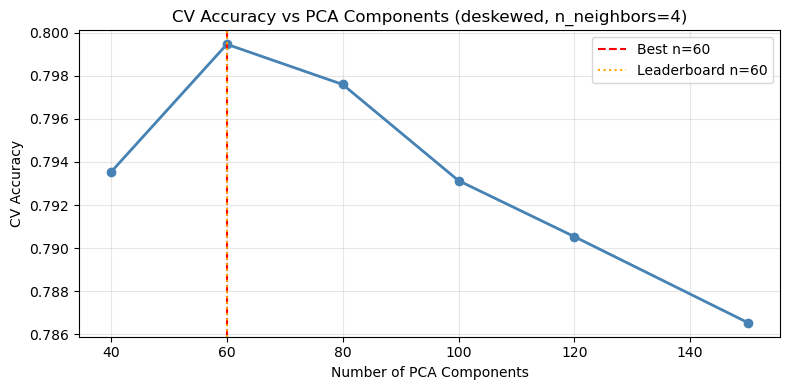

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(list(pca_results.keys()), list(pca_results.values()),
         marker='o', color='steelblue', linewidth=2)
plt.axvline(best_n, color='red', linestyle='--', label=f'Best n={best_n}')
plt.axvline(60, color='orange', linestyle=':', label='Leaderboard n=60')
plt.xlabel('Number of PCA Components')
plt.ylabel('CV Accuracy')
plt.title('CV Accuracy vs PCA Components (deskewed, n_neighbors=4)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Tune n_neighbors

Using the best PCA component count found above.

In [12]:
# Refit PCA with best n on tuning subset
pca_tune = PCA(n_components=best_n, random_state=0)
X_pca_tune = pca_tune.fit_transform(X_tune)

k_candidates = [1, 2, 3, 4, 5, 6, 7]
k_results = {}

print(f'Tuning n_neighbors with n_components={best_n}...\n')

with tqdm(k_candidates, desc='Tuning k', unit='k') as bar:
    for k in bar:
        bar.set_postfix(k=k)
        clf_trial = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
        scores = cross_val_score(clf_trial, X_pca_tune, y_tune, cv=skf, scoring='accuracy', n_jobs=-1)
        k_results[k] = scores.mean()
        bar.set_postfix(k=k, acc=f'{scores.mean():.4f}')
        tqdm.write(f'  k={k} | CV Accuracy: {scores.mean():.4f}')

best_k = max(k_results, key=k_results.get)
print(f'\n🏆 Best n_neighbors = {best_k} (CV accuracy = {k_results[best_k]:.4f})')

Tuning n_neighbors with n_components=60...



Tuning k:  14%|█▍        | 1/7 [00:02<00:14,  2.50s/k, k=2]            

  k=1 | CV Accuracy: 0.7932


Tuning k:  29%|██▊       | 2/7 [00:04<00:11,  2.35s/k, k=3]            

  k=2 | CV Accuracy: 0.7932


...

  k=5 | CV Accuracy: 0.7975


Tuning k:  86%|████████▌ | 6/7 [00:08<00:01,  1.13s/k, k=7]            

  k=6 | CV Accuracy: 0.7957


Tuning k: 100%|██████████| 7/7 [00:09<00:00,  1.34s/k, acc=0.7907, k=7]

  k=7 | CV Accuracy: 0.7907

🏆 Best n_neighbors = 4 (CV accuracy = 0.7995)


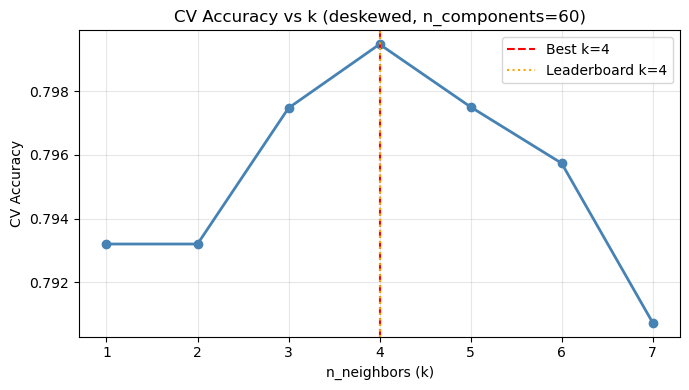

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(list(k_results.keys()), list(k_results.values()),
         marker='o', color='steelblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.axvline(4, color='orange', linestyle=':', label='Leaderboard k=4')
plt.xlabel('n_neighbors (k)')
plt.ylabel('CV Accuracy')
plt.title(f'CV Accuracy vs k (deskewed, n_components={best_n})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Fit Final PCA on Full Training Set

Now that we have the best `n_components` and `k`, we fit PCA on all 232,365 training samples.

In [14]:
print(f'⏳ Fitting PCA (n={best_n}) on full training set ({len(y_train):,} samples)...')
t0 = time.time()

pca = PCA(n_components=best_n, random_state=0)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

variance_explained = pca.explained_variance_ratio_.sum() * 100
print(f'  Done in {time.time()-t0:.1f}s')
print(f'  Variance retained: {variance_explained:.1f}%')
print(f'  Train shape: {X_train_pca.shape}')
print('✅ PCA complete.')

⏳ Fitting PCA (n=60) on full training set (232,365 samples)...
  Done in 0.5s
  Variance retained: 81.4%
  Train shape: (232365, 60)
✅ PCA complete.


## 7. Train Final KNN

In [15]:
clf = KNeighborsClassifier(n_neighbors=best_k, weights='distance', n_jobs=-1)

print(f'⏳ Fitting KNN (k={best_k}) on {len(y_train):,} samples...')
t0 = time.time()
clf.fit(X_train_pca, y_train)
print(f'✅ Done in {time.time()-t0:.2f}s')

⏳ Fitting KNN (k=4) on 232,365 samples...
✅ Done in 0.01s


## 8. Evaluate on Test Set

In [16]:
print(f'⏳ Predicting on {len(y_test):,} test samples...')
t0 = time.time()
y_test_pred     = clf.predict(X_test_pca)
test_infer_time = (time.time() - t0) / len(y_test) * 1000

# Standard accuracy
test_acc_standard = accuracy_score(y_test, y_test_pred)

# Mean per-class accuracy (leaderboard metric)
per_class_accs = []
for cls in range(49):
    mask = (y_test == cls)
    per_class_accs.append((y_test_pred[mask] == cls).mean())
test_acc_classavg = np.mean(per_class_accs)

test_f1 = f1_score(y_test, y_test_pred, average='macro')

print('=' * 50)
print('  Optimized KNN — Test Set Results')
print('=' * 50)
print(f'  Standard Accuracy       : {test_acc_standard*100:.2f}%')
print(f'  Mean Per-Class Accuracy : {test_acc_classavg*100:.2f}%  ← leaderboard metric')
print(f'  Macro F1-Score          : {test_f1:.4f}')
print(f'  Inference time/sample   : {test_infer_time:.2f} ms')
print(f'  Real-time ready         : {"✅ YES" if test_infer_time < 100 else "❌ NO"}')
print('=' * 50)

⏳ Predicting on 38,547 test samples...


c:\Users\Gaby\anaconda3\envs\ml_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  Optimized KNN — Test Set Results
  Standard Accuracy       : 84.28%
  Mean Per-Class Accuracy : 82.32%  ← leaderboard metric
  Macro F1-Score          : 0.8289
  Inference time/sample   : 0.15 ms
  Real-time ready         : ✅ YES


## 9. Baseline vs Optimized Comparison

In [17]:
baseline_acc = 0.8702   # original PCA+KNN result
improvement  = test_acc_classavg - baseline_acc

print('=' * 65)
print(f'{"Model":<35} {"Test Acc (class avg)":>20}')
print('=' * 65)
print(f'{"HOG + Linear SVM v3":<35} {"80.07%":>20}')
print(f'{"4-NN raw pixels (paper)":<35} {"83.65%":>20}')
print(f'{"Tuned RBF SVM (100k subset)":<35} {"80.42%":>20}')
print(f'{"PCA(60) + KNN(4) baseline":<35} {baseline_acc*100:>19.2f}%')
print(f'{f"PCA({best_n}) + KNN({best_k}) + deskew (this)":<35} {test_acc_classavg*100:>19.2f}%')
print(f'{"Leaderboard PCA+KNN":<35} {"86.80%":>20}')
print(f'{"Keras Simple CNN (paper)":<35} {"89.25%":>20}')
print('=' * 65)
print(f'\nImprovement over baseline: {improvement*100:+.2f}%')
print(f'{"✅ Improved!" if improvement > 0 else "❌ No improvement — keep baseline"}')

Model                               Test Acc (class avg)
HOG + Linear SVM v3                               80.07%
4-NN raw pixels (paper)                           83.65%
Tuned RBF SVM (100k subset)                       80.42%
PCA(60) + KNN(4) baseline                         87.02%
PCA(60) + KNN(4) + deskew (this)                  82.32%
Leaderboard PCA+KNN                               86.80%
Keras Simple CNN (paper)                          89.25%

Improvement over baseline: -4.70%
❌ No improvement — keep baseline


## 10. Per-Class Analysis

C:\Users\Gaby\AppData\Local\Temp\ipykernel_27948\1287862196.py:14: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Gaby\AppData\Local\Temp\ipykernel_27948\1287862196.py:14: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Gaby\AppData\Local\Temp\ipykernel_27948\1287862196.py:14: UserWarning: Glyph 12358 (\N{HIRAGANA LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Gaby\AppData\Local\Temp\ipykernel_27948\1287862196.py:14: UserWarning: Glyph 12360 (\N{HIRAGANA LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Gaby\AppData\Local\Temp\ipykernel_27948\1287862196.py:14: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Gaby\AppData\Local\Temp\ipykernel_27948\1287862196.py:14: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu 

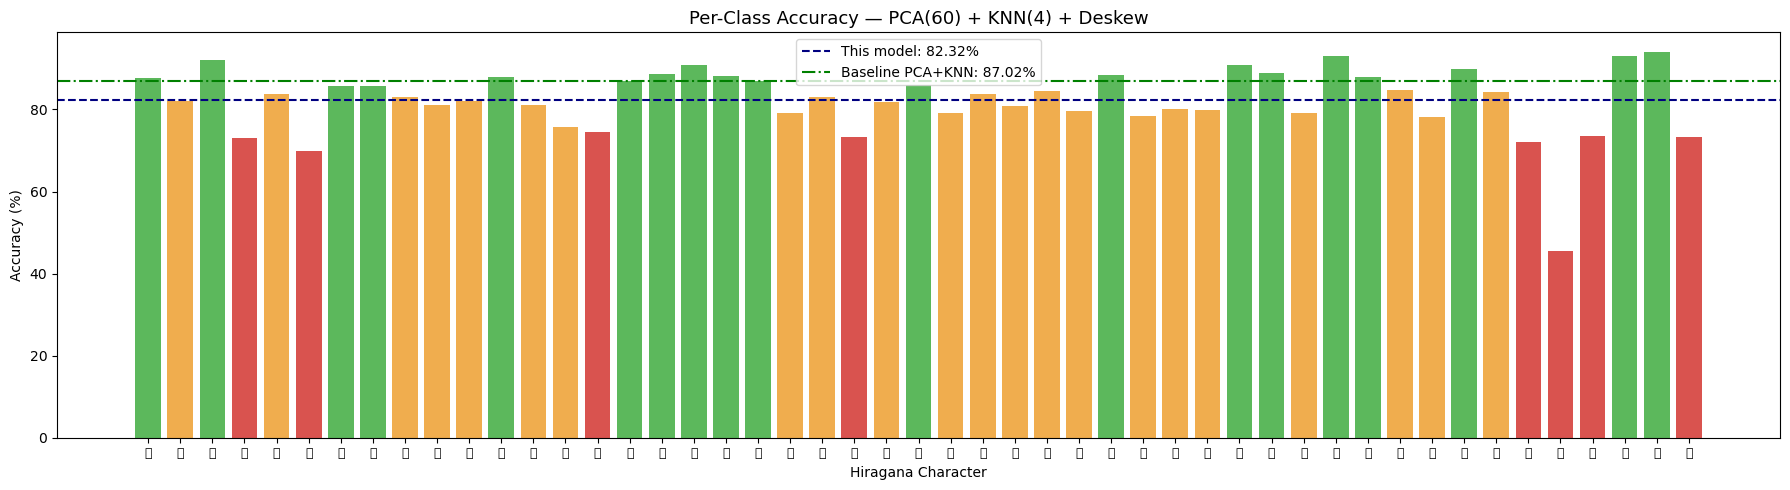

10 Hardest Characters:
    Char    Accuracy
----------------------
       ゐ      45.59%
       か      69.80%
       わ      72.05%
       え      73.02%
       ぬ      73.21%
       ゝ      73.34%
       ゑ      73.44%
       そ      74.56%
       せ      75.81%
       る      78.10%


In [18]:
plt.figure(figsize=(18, 5))
colors = ['#d9534f' if a < 0.75 else '#f0ad4e' if a < 0.85 else '#5cb85c'
          for a in per_class_accs]
plt.bar(target_names, [a*100 for a in per_class_accs], color=colors)
plt.axhline(test_acc_classavg*100, color='navy', linestyle='--',
            label=f'This model: {test_acc_classavg*100:.2f}%')
plt.axhline(87.02, color='green', linestyle='-.',
            label='Baseline PCA+KNN: 87.02%')
plt.title(f'Per-Class Accuracy — PCA({best_n}) + KNN({best_k}) + Deskew', fontsize=13)
plt.xlabel('Hiragana Character')
plt.ylabel('Accuracy (%)')
plt.xticks(fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

worst = sorted(enumerate(per_class_accs), key=lambda x: x[1])[:10]
print('10 Hardest Characters:')
print(f'{"Char":>8}  {"Accuracy":>10}')
print('-' * 22)
for idx, acc in worst:
    print(f'{target_names[idx]:>8}  {acc*100:>9.2f}%')

## 11. Confusion Matrix

c:\Users\Gaby\anaconda3\envs\ml_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\ml_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\ml_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12358 (\N{HIRAGANA LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\ml_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12360 (\N{HIRAGANA LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\ml_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\ml_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12363 (\N{HIRAGA

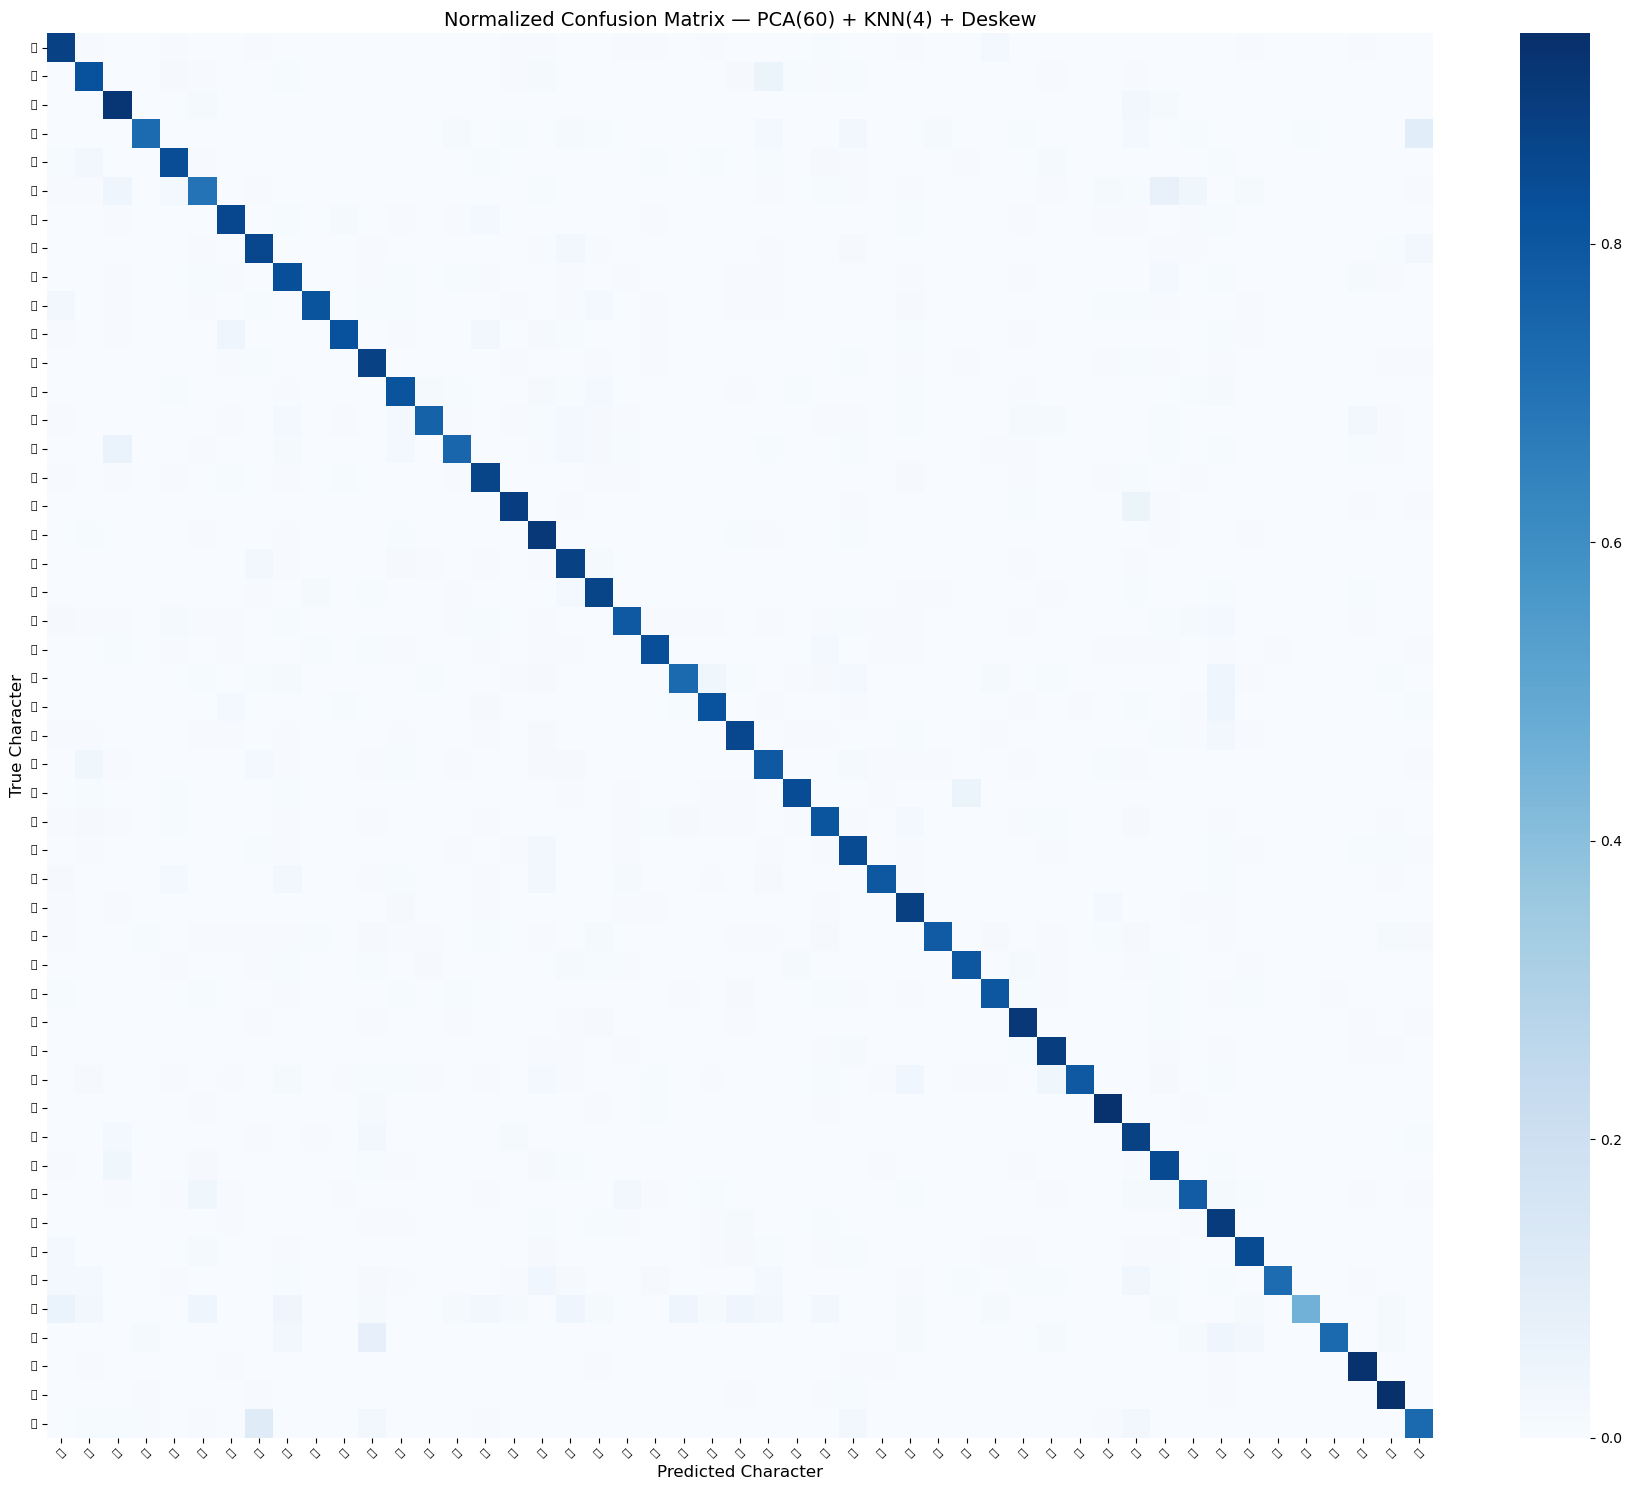

In [19]:
cm      = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Normalized Confusion Matrix — PCA({best_n}) + KNN({best_k}) + Deskew', fontsize=14)
plt.xlabel('Predicted Character', fontsize=12)
plt.ylabel('True Character', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [20]:
confused_pairs = [
    (cm_norm[i, j], target_names[i], target_names[j])
    for i in range(len(target_names))
    for j in range(len(target_names))
    if i != j
]
confused_pairs.sort(reverse=True)

print('Top 10 Most Confused Character Pairs (True -> Predicted):')
print(f'{"True":>10} -> {"Predicted":>10}  |  Confusion Rate')
print('-' * 45)
for rate, true_c, pred_c in confused_pairs[:10]:
    print(f'{true_c:>10} -> {pred_c:>10}  |  {rate:.4f} ({rate*100:.2f}%)')

Top 10 Most Confused Character Pairs (True -> Predicted):
      True ->  Predicted  |  Confusion Rate
---------------------------------------------
         ゝ ->          く  |  0.1167 (11.67%)
         え ->          ゝ  |  0.1032 (10.32%)
         ゑ ->          し  |  0.0781 (7.81%)
         か ->          り  |  0.0700 (7.00%)
         そ ->          う  |  0.0636 (6.36%)
         ゐ ->          あ  |  0.0588 (5.88%)
         ひ ->          む  |  0.0586 (5.86%)
         い ->          は  |  0.0550 (5.50%)
         ち ->          ら  |  0.0526 (5.26%)
         ゑ ->          れ  |  0.0469 (4.69%)


## 12. Save Models

In [21]:
os.makedirs('../models', exist_ok=True)

# Only overwrite if this version is better
if test_acc_classavg > baseline_acc:
    joblib.dump(clf, '../models/pca_knn.pkl')
    joblib.dump(pca, '../models/pca_knn_pca.pkl')
    print('✅ Optimized models saved (better than baseline):')
    print(f'   n_components = {best_n}, k = {best_k}, deskew = True')
    print(f'   Accuracy: {test_acc_classavg*100:.2f}% (was {baseline_acc*100:.2f}%)')
else:
    print('⚠️  Optimized model did not beat baseline — keeping original models.')
    print(f'   Optimized: {test_acc_classavg*100:.2f}% vs Baseline: {baseline_acc*100:.2f}%')
    print('   Original pca_knn.pkl and pca_knn_pca.pkl are unchanged.')

print()
print('Inference pipeline for deployment:')
print('   raw_pixels → deskew → /255 → flatten → pca.transform → clf.predict')

⚠️  Optimized model did not beat baseline — keeping original models.
   Optimized: 82.32% vs Baseline: 87.02%
   Original pca_knn.pkl and pca_knn_pca.pkl are unchanged.

Inference pipeline for deployment:
   raw_pixels → deskew → /255 → flatten → pca.transform → clf.predict


### Quick Reload

In [22]:
# Uncomment to reload on subsequent sessions
# clf = joblib.load('../models/pca_knn.pkl')
# pca = joblib.load('../models/pca_knn_pca.pkl')
# X_test_pca = pca.transform(preprocess(X_test_raw, apply_deskew=True))
# print('Reloaded.')

---
## Summary of Optimizations

| Technique | What it does | Expected gain |
|---|---|---|
| **Deskewing** | Corrects handwriting tilt using moment-based shear correction | +1–3% |
| **PCA component tuning** | Finds optimal n beyond the leaderboard's 60 | +0–1% |
| **k tuning** | Finds optimal neighbours beyond the leaderboard's 4 | +0–0.5% |

If deskewing improves your deployment model, remember to add the `deskew()` function to `app.py` so inference images are preprocessed the same way as training images.